In [1]:
import os
import glob
import numpy as np
import re 

import matplotlib.pyplot as plt

_flat_cache = {}

def load_flatpack(k_index, flat_dir="lambda_singlet"):
    """
    Load and cache flat-band data for a given k_index.
    Expects files named flat_kXXXXX.npz inside flat_dir.
    """
    k_index = int(k_index)
    key = (flat_dir, k_index)
    if key in _flat_cache:
        return _flat_cache[key]

    path = os.path.join(flat_dir, f"flat_k{k_index:05d}.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    z = np.load(path, allow_pickle=True)
    pack = {
        "L0flat":     z["L0flat"],          # shape: (3, N, N)
        "L1flat":     z["L1flat"],          # shape: (3, N, N)
        "Eplus_flat":  z["Eplus_flat"],     # shape: (N,)
        "Eminus_flat": z["Eminus_flat"],    # shape: (N,)
        "k":          z["k"],
        "k_index":    int(z["k_index"]),
    }
    _flat_cache[key] = pack
    return pack

# ------------------------------------------------------------
# Helper: centered subspace indices
# ------------------------------------------------------------
def _center_indices(N, subspace_dim):
    """
    Return indices for a centered subspace of size subspace_dim inside 0..N-1.
    """
    if subspace_dim > N:
        raise ValueError(f"subspace_dim={subspace_dim} > full dim N={N}")
    start = (N - subspace_dim) // 2
    end   = start + subspace_dim
    return np.arange(start, end, dtype=int)

# ------------------------------------------------------------
# Flat-band BdG Hamiltonian (restricted subspace)
# ------------------------------------------------------------
def flat_BdG(pack, *, DeltaLayer0, DeltaLayer1, mu,
             subspace_dim=10):
    """
    Build flat-band BdG Hamiltonian in a centered subspace of size subspace_dim.
    Δ0, Δ1 are length-3 complex arrays (one component per Kekulé irrep).
    """
    Δ0 = np.asarray(DeltaLayer0, complex).ravel()
    Δ1 = np.asarray(DeltaLayer1, complex).ravel()
    if Δ0.size != 3 or Δ1.size != 3:
        raise ValueError("DeltaLayer0/1 must each have length 3.")

    Eplus  = np.asarray(pack["Eplus_flat"],  float)
    Eminus = np.asarray(pack["Eminus_flat"], float)
    L0flat = np.asarray(pack["L0flat"])   # (3, N, N)
    L1flat = np.asarray(pack["L1flat"])   # (3, N, N)

    N = Eplus.shape[0]
    idx = _center_indices(N, subspace_dim)

    # restrict to subspace
    Eplus_sub  = Eplus[idx]
    Eminus_sub = Eminus[idx]
    L0_sub = L0flat[:, idx][:, :, idx]   # (3, subspace_dim, subspace_dim)
    L1_sub = L1flat[:, idx][:, :, idx]   # (3, subspace_dim, subspace_dim)

    Fp = np.diag(Eplus_sub)
    Fm = -np.diag(Eminus_sub)

    # pairing: here only sym = 0 component used; Lflat is mathematical Λ
    Gap_flat = Δ0[0] * np.conj(L0_sub[0]) + Δ1[0] * np.conj(L1_sub[0])

    I = np.eye(Fp.shape[0], dtype=complex)
    HLL = np.block([
        [Fp - mu * I,          Gap_flat        ],
        [Gap_flat.conj().T,    Fm + mu * I     ]
    ]).astype(complex)

    return HLL, Gap_flat 



def delta(x,sigma):
    return np.exp(-0.5*(x/sigma)**2) / (np.sqrt(2*np.pi)*sigma)

def thermal_delta(x, T):
    """
    Recommended, numerically stable:  (1/(4T)) * sech^2(x/(2T))
    This equals  -d f_FD(x)/dx  and is always >= 0.
    """
    x = np.asarray(x, dtype=float)
    T = float(T)
    y = x / (2.0*T)
    # sech^2(y) = 1 / cosh(y)^2 is stable even for large |y|
    return (1.0 / (4.0*T)) * (1.0 / np.cosh(y)**2)


def DOS(pack, *, omega,DeltaLayer0, DeltaLayer1,mu,subspace_dim=10):
    #
    HLL, _ = flat_BdG(pack, DeltaLayer0=DeltaLayer0, DeltaLayer1=DeltaLayer1,mu=mu,subspace_dim=subspace_dim)
    E, U = np.linalg.eigh(HLL)
    n = HLL.shape[0] // 2
    # 
    # 
    sigma=5e-5;
    t = delta(omega-E,sigma)  
    G = (U * t) @ U.conj().T                 
    F = np.trace(G[0:n, 0:n] )                                   
    return F

 
def Sum_DOS(*,omega, DeltaLayer0, DeltaLayer1, mu, flat_dir="lambda_flat_singlet", average=True,subspace_dim=10):
    #  
    files = sorted(fn for fn in os.listdir(flat_dir) if re.match(r"flat_k\d{5}\.npz$", fn))
    if not files:
        raise FileNotFoundError(f"No flat_kXXXXX.npz files found in {flat_dir}")
    acc0 = 0j; acc1 = 0j; Nk = 0
    for fn in files:
        pack = load_flatpack(int(fn[6:11]), flat_dir=flat_dir)
        F  = DOS(pack,omega=omega, DeltaLayer0=DeltaLayer0, DeltaLayer1=DeltaLayer1,mu=mu,subspace_dim=subspace_dim)
        acc0 += F   #
        Nk += 1
    if average and Nk:
        acc0 /= Nk;
    return acc0

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams["font.family"] = "STIXGeneral"

#  
def read_posthoc(npz_path):
    z = np.load(npz_path)
    T   = np.asarray(z["Ts"], float)
    ok  = np.asarray(z["success"], bool)
    d0  = np.asarray(z["d0_re"], float) + 1j*np.asarray(z["d0_im"], float)
    d1  = np.asarray(z["d1_re"], float) + 1j*np.asarray(z["d1_im"], float)
    mu  = np.asarray(z["mu"], float)
    return T, ok, d0,d1,mu

#  
base = "fig3"
V_list = [1]
paths = {V: os.path.join(base, f"V={V}", "posthoc_results.npz") for V in V_list}

#  
ax.set_facecolor('none')        # <<< turn off axes background (keep axes/spines)

missing = []
for V in sorted(V_list):
    path = paths[V]
    if not os.path.isfile(path):
        missing.append(path)
        continue

    T, ok, d0,d1,Mu = read_posthoc(path)



In [3]:
 
sym=0;
Δ0_vec = np.zeros(3, complex); Δ1_vec = np.zeros(3, complex);
### Just initialize purpouse
Δ0=0.00032513598;
Δ1=0.00032513598;
mu=0.0011161834

omega=0;
sym=0;subspace_dim=10
Δ0_vec = np.zeros(3, complex); Δ1_vec = np.zeros(3, complex);
Δ0_vec[sym] = Δ0; Δ1_vec[sym] = Δ1 
#  
ReDOS = []
for i in range(d0.size):
    Δ0_vec[sym] = d0[i]; Δ1_vec[sym] = d1[i];
    mua=Mu[i];
    acc0 = Sum_DOS(
        omega=0,
        DeltaLayer0=Δ0_vec,
        DeltaLayer1=Δ1_vec,
        mu=mua,
        flat_dir="lambda_triplet",
        average=True
    )
    ReDOS.append(np.real(acc0))

ReDOS = np.array(ReDOS )

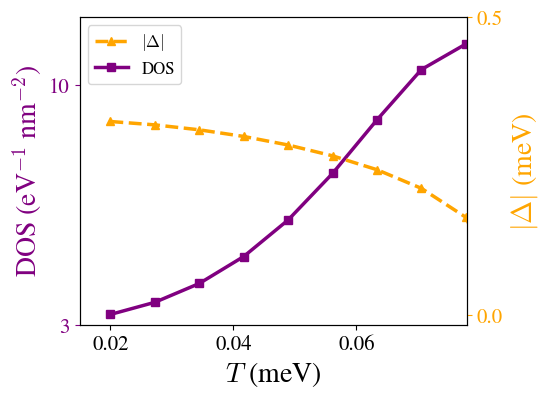

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))

# --- Left axis: DOS (was on ax2) ---
m1, = ax.plot(1000*T, ReDOS*0.2/(2*np.pi)**2, "s-", lw=2.5, ms=5.5,
              label=r"DOS", color="purple")
ax.set_xlabel(r"$T$ (meV)", fontsize=20)
ax.set_ylabel(r"DOS (eV$^{-1}$ nm$^{-2}$)", fontsize=20, color="purple")
ax.tick_params(labelsize=15, axis="y", colors="purple")

# --- Right axis: |Δ| (was on ax) ---
ax2 = ax.twinx()
l1, = ax2.plot(1000*T, 1000*np.abs(d0), "^--", color="orange", lw=2.5, ms=6,
               label=r"$|\Delta|$")
ax2.set_ylabel(r"$|\Delta|$ (meV)", fontsize=20, color="orange")
ax2.tick_params(labelsize=15, axis="y", colors="orange")

# Limits / ticks
ax.set_xlim(0.015, 0.078)

ax.set_yticks([3, 10])
ax.set_ylim(3, 12)

ax2.set_yticks([0.0, 0.5])
# (optional) if you also want explicit right-axis limits:
# ax2.set_ylim(0.0, 0.5)
ax.set_xticks([0.02, 0.04,0.06])
ax.tick_params(labelsize=15)
ax2.tick_params(labelsize=15)
# Legend (order: |Δ| then DOS, or swap if you prefer)
handles = [l1, m1]
labels  = [h.get_label() for h in handles]
ax.legend(handles, labels, loc="best", fontsize=12)

plt.savefig("figs/fig7.pdf", bbox_inches="tight")
